In [182]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



In [183]:
df_new=pd.read_csv(r"C:\Users\Darsh\OneDrive\Desktop\AIML_personal\Dataset\House-Price-regression\train.csv")
df=df_new.copy()
X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [184]:

# df=df.drop(columns="")

# print(df.groupby("LotShape")["SalePrice"].mean())
lotshape_map = {   #ordinal encoding verified from mean price
    "Reg": 0,
    "IR1": 1,
    "IR3": 2,
    "IR2": 3
}
df["LotShape_encoded"] = df["LotShape"].map(lotshape_map)
# print(df[["LotShape", "LotShape_encoded"]].head())
df=df.drop(columns=["LotShape"])
df=df.drop(columns=["Id"])
df = pd.get_dummies(df, columns=["MSZoning"],dtype=int) #one hot encoding in this 
# print(df.columns)
df = pd.get_dummies(df, columns=["LandContour"], dtype=int)
df["MSSubClass"] = df["MSSubClass"].astype(str)
df = pd.get_dummies(df, columns=["MSSubClass"], dtype=int)
# print(df.shape)

df["LotArea_log"] = np.log1p(df["LotArea"])
scaler = StandardScaler()

df["LotArea_scaled"] = scaler.fit_transform(df[["LotArea_log"]])
print(df["LotArea_scaled"])
df["LotFrontage"] = df.groupby("Neighborhood")["LotFrontage"].transform(
    lambda x: x.fillna(x.median())
)
df["LotFrontage"].fillna(df["LotFrontage"].median(), inplace=True)
print(df["LotFrontage"])
df=pd.get_dummies(df, columns=["Street"], drop_first=True, dtype=int)

# df["column_name"].unique() display unique values in that particular column

# print(df["Street"])
# df=pd.get_dummies(df,columns=["Street"],dtype=int)

df=pd.get_dummies(df,columns=["Alley"],dtype=int)
df=df.drop(columns=["Utilities"])


0      -0.133270
1       0.113413
2       0.420049
3       0.103317
4       0.878431
          ...   
1455   -0.259231
1456    0.725429
1457   -0.002359
1458    0.136833
1459    0.180116
Name: LotArea_scaled, Length: 1460, dtype: float64
0       65.0
1       80.0
2       68.0
3       60.0
4       84.0
        ... 
1455    62.0
1456    85.0
1457    66.0
1458    68.0
1459    75.0
Name: LotFrontage, Length: 1460, dtype: float64


C:\Users\Darsh\AppData\Local\Temp\ipykernel_23284\1092684963.py:29: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["LotFrontage"].fillna(df["LotFrontage"].median(), inplace=True)


In [185]:
print(df["LotConfig"].value_counts(normalize=True)) # it gives % of occurence of value
# df["LotConfig"].unique() #is used for finding all unique values
df["LotConfig"].describe()
df=pd.get_dummies(df,columns=["LotConfig"],drop_first=True,dtype=int)
df.shape
"LotConfig" in df.columns

LotConfig
Inside     0.720548
Corner     0.180137
CulDSac    0.064384
FR2        0.032192
FR3        0.002740
Name: proportion, dtype: float64


False

In [186]:
df.groupby("LandSlope")["SalePrice"].mean()

# mapping_for_LandSlope{
#     "Gtl":0;
#     "Mod":1;
#     "Sev":2;
# }
# df[LandSlope_encoded]=df["LandSlope"].map(mapping_for_LandSlope)

df=pd.get_dummies(df,columns=["LandSlope"],drop_first=True,dtype=int)  #this is using same df and updating df becoz of which we are droping 
#og column and 1 column too that is if 3 distinct values are there we will hve only 2 columns with 1 drop

# pd.get_dummies(df["LandSlope"]) # this will not drop og column becoz and it will give only encoded data

df.columns
# df=df.drop(columns=["LandSlope"])
# sns.boxplot(x="LandSlope",y="SalePrice",data=df)

#here we hve seen that gtl has roughly same values and it has lowest median among all 3 while median for rest both that is mod and sev has
#same median for that reason we can't do oridinal encoding another reason is outliers/circles says that even though land is flat we are 
#having many houses at higher price so our assumption that sev or slop land costs more price is wrong

Index(['LotFrontage', 'LotArea', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt',
       ...
       'LotArea_scaled', 'Street_Pave', 'Alley_Grvl', 'Alley_Pave',
       'LotConfig_CulDSac', 'LotConfig_FR2', 'LotConfig_FR3',
       'LotConfig_Inside', 'LandSlope_Mod', 'LandSlope_Sev'],
      dtype='object', length=107)

In [187]:
df["LandSlope_Mod"]

0       0
1       0
2       0
3       0
4       0
       ..
1455    0
1456    0
1457    0
1458    0
1459    0
Name: LandSlope_Mod, Length: 1460, dtype: int64

In [188]:
# model.feature_importances_ for knowing how much each feature is important in a model

In [189]:
df.columns

Index(['LotFrontage', 'LotArea', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt',
       ...
       'LotArea_scaled', 'Street_Pave', 'Alley_Grvl', 'Alley_Pave',
       'LotConfig_CulDSac', 'LotConfig_FR2', 'LotConfig_FR3',
       'LotConfig_Inside', 'LandSlope_Mod', 'LandSlope_Sev'],
      dtype='object', length=107)

In [190]:
df.groupby("Neighborhood")["SalePrice"].mean().sort_values()
# sns.barplot(x="Neighborhood",y="SalePrice",data=df)
mapping = df.groupby("Neighborhood")["SalePrice"].mean()
df["Neighborhood_encoded"] = df["Neighborhood"].map(mapping)

#we have not used one hot encoding here becoz if we convert it into one hot it will be 24 columns which is too big data instead of this
# it we are using target encoding which will give us avg of that particular grp and will replace it with its mean value

In [191]:
df["Neighborhood_encoded"]

0       197965.773333
1       238772.727273
2       197965.773333
3       210624.725490
4       335295.317073
            ...      
1455    192854.506329
1456    189050.068493
1457    210624.725490
1458    145847.080000
1459    128219.700000
Name: Neighborhood_encoded, Length: 1460, dtype: float64

In [192]:
df["Condition_combined"] = df["Condition1"] + "_" + df["Condition2"]
df.groupby("Condition_combined")["SalePrice"].mean().sort_values()
mapping_combined_condition=df.groupby("Condition_combined")["SalePrice"].mean()
df["Condition_combined_encoded"]=df["Condition_combined"].map(mapping_combined_condition)
df=df.drop(columns=["Condition1","Condition2"])

In [193]:
df.groupby("BldgType")["SalePrice"].mean().sort_values()
df["BldgType_grouped"] = df["BldgType"].map({
    "2fmCon": "Low",
    "Duplex": "Low",
    "Twnhs": "Low",
    "TwnhsE": "High",
    "1Fam": "High"
})
df=pd.get_dummies(df,columns=["BldgType_grouped"], drop_first=True,dtype=int)
df.columns

Index(['LotFrontage', 'LotArea', 'Neighborhood', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       ...
       'LotConfig_CulDSac', 'LotConfig_FR2', 'LotConfig_FR3',
       'LotConfig_Inside', 'LandSlope_Mod', 'LandSlope_Sev',
       'Neighborhood_encoded', 'Condition_combined',
       'Condition_combined_encoded', 'BldgType_grouped_Low'],
      dtype='object', length=109)

In [194]:
df.groupby("HouseStyle")["SalePrice"].mean().sort_values()
NumFloors= df["HouseStyle"].map({
    "1Story": 1,
    "1.5Fin": 1.5,
    "1.5Unf": 1.5,
    "SFoyer": 1.5,
    "SLvl": 2,
    "2Story": 2,
    "2.5Unf": 2.5,
    "2.5Fin": 2.5
})
df["Number_Of_floors_encoded"]=df["HouseStyle"].map(NumFloors)
# df=df.drop(columns=["HouseStyle","NumFloors"])

In [195]:
df["Quality_vs_Condition"] = df["OverallQual"] - df["OverallCond"]

# Good build but poor maintenance

In [196]:
Current_Year=2026
df["House_Age"]=Current_Year-df["YearBuilt"]
df=df.drop(columns=["YearBuilt"])


In [197]:
df["House_Age"]

0        23
1        50
2        25
3       111
4        26
       ... 
1455     27
1456     48
1457     85
1458     76
1459     61
Name: House_Age, Length: 1460, dtype: int64

In [198]:
current_year=2026
df["Rennovated_age"]=current_year-df["YearRemodAdd"]
df=df.drop(columns=["YearRemodAdd"])


In [199]:
# df.groupby("RoofStyle")["SalePrice"].mean().sort_values()
df=pd.get_dummies(df,columns=["RoofStyle"],drop_first=True,dtype=int)


In [200]:
df.groupby("RoofMatl")["SalePrice"].mean().sort_values()
RoofMatl_grouped= df["RoofMatl"].map({
    "Roll": "Low",
    "ClyTile": "Low",
    "CompShg": "Low",
    "Metal": "Low",
    "Tar&Grv": "High",
    "WdShake": "High",
    "Membran": "High",
    "WdShngl": "High"
})
df["RoofMatl"].value_counts()
df["RoofMaterial_Encoded"]=df["RoofMatl"].map(RoofMatl_grouped)

In [201]:
df.groupby("Exterior1st")["SalePrice"].mean().sort_values()
def group_exterior(x):
    if x in ["HdBoard", "MetalSd", "Wd Sdng"]:
        return "Common"
    elif x in ["CemntBd", "BrkFace","VinylSd","Plywood"]:
        return "Premium"
    else:
        return "Rare"

df["Exterior1st_grouped"] = df["Exterior1st"].apply(group_exterior)
df=pd.get_dummies(df,columns=["Exterior1st_grouped"],drop_first=True,dtype=int)

In [202]:
# df.groupby("Exterior1st")["SalePrice"].mean().value_counts()
(df["Exterior1st"] == df["Exterior2nd"]).mean()
df["Exterior_same"] = (df["Exterior1st"] == df["Exterior2nd"]).astype(int)
df=df.drop(columns=["Exterior2nd"])

In [203]:
df["MasVnrType"]=df["MasVnrType"].fillna("None")

In [204]:
df.groupby("MasVnrType")["SalePrice"].mean()
df["MasVnrType"].value_counts()
df=pd.get_dummies(df,columns=["MasVnrType"],drop_first=True,dtype=int)

In [205]:
df["MasVnrArea"] = df["MasVnrArea"].fillna(0)

In [206]:
df.groupby("ExterQual")["SalePrice"].mean()
mapping = {
    "Po": 1,
    "Fa": 2,
    "TA": 3,
    "Gd": 4,
    "Ex": 5
}

df["ExterQual"] = df["ExterQual"].map(mapping)
df["ExterQual"].head()


0    4
1    3
2    4
3    3
4    4
Name: ExterQual, dtype: int64

In [207]:
df["ExterCond"].unique()
mapping={
    "Po": 1,
    "Fa": 2,
    "TA": 3,
    "Gd": 4,
    "Ex": 5
}
df["ExterCond"]=df["ExterCond"].map(mapping)
df["ExterCond"].unique()

array([3, 4, 2, 1, 5])

In [208]:
df.groupby("Foundation")["SalePrice"].mean().sort_values()
df["Foundation"].value_counts()
def foundation_quality(x):
    if x=="PConc":
        return "Premium"
    elif x=="BrkTil" or x=="CBlock":
        return "Mid"
    else:
        return "Basic"
df["Foundation"]=df["Foundation"].apply(foundation_quality)
df=pd.get_dummies(df,columns=["Foundation"],drop_first=True ,dtype=int)


In [209]:
df.columns

Index(['LotFrontage', 'LotArea', 'Neighborhood', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'RoofMatl', 'Exterior1st', 'MasVnrArea',
       ...
       'RoofStyle_Shed', 'RoofMaterial_Encoded', 'Exterior1st_grouped_Premium',
       'Exterior1st_grouped_Rare', 'Exterior_same', 'MasVnrType_BrkFace',
       'MasVnrType_None', 'MasVnrType_Stone', 'Foundation_Mid',
       'Foundation_Premium'],
      dtype='object', length=121)

In [210]:
df.groupby("BsmtQual")["SalePrice"].mean().sort_values()
# df["BsmtQual"].unique()
mapping={
    "Fa": 1,
    "TA": 2,
    "Gd": 3,
    "Ex": 4
}
df["BsmtQual_Encoded"]=df["BsmtQual"].map(mapping)
df["BsmtQual_Encoded"]=df["BsmtQual_Encoded"].fillna(0)
df=df.drop(columns=["BsmtQual"])

In [211]:
mapping = {
    "Po": 1,
    "Fa": 2,
    "TA": 3,
    "Gd": 4
}
df["BsmtCond"]=df["BsmtCond"].map(mapping)
df["BsmtCond"]=df["BsmtCond"].fillna(0)

In [212]:
df["BsmtCond"].unique()

array([3., 4., 0., 2., 1.])

In [213]:
df.groupby("BsmtExposure")["SalePrice"].mean().sort_values()
df["BsmtExposure"].unique()

array(['No', 'Gd', 'Mn', 'Av', nan], dtype=object)

In [214]:
mapping={
    "No": 1,
    "Mn": 2,
    "Av": 3,
    "Gd": 4
}
df["BsmtExposure"]=df["BsmtExposure"].map(mapping).fillna(0)

In [215]:
df["BsmtExposure"].unique()

array([1., 4., 2., 3., 0.])

In [216]:
mapping = {
    "Unf": 1,
    "LwQ": 2,
    "Rec": 3,
    "BLQ": 4,
    "ALQ": 5,
    "GLQ": 6
}

df["BsmtFinType1"] = df["BsmtFinType1"].map(mapping).fillna(0)

In [217]:
df["BsmtFinType1"].unique()

array([6., 5., 1., 3., 4., 0., 2.])

In [ ]:
df["HasBsmtFinSF2"] = (df["BsmtFinSF2"] > 0).astype(int)
df["HasBsmtFinSF2"].head()
df=df.drop(columns=["BsmtFinSF2"])

In [222]:
mapping = {
    "Unf": 1,
    "LwQ": 2,
    "Rec": 3,
    "BLQ": 4,
    "ALQ": 5,
    "GLQ": 6
}

df["BsmtFinType2"] = df["BsmtFinType2"].map(mapping).fillna(0)

In [223]:
df["BsmtUnfSF"] = np.log1p(df["BsmtUnfSF"])

In [224]:
df.columns

Index(['LotFrontage', 'LotArea', 'Neighborhood', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'RoofMatl', 'Exterior1st', 'MasVnrArea',
       ...
       'Exterior1st_grouped_Premium', 'Exterior1st_grouped_Rare',
       'Exterior_same', 'MasVnrType_BrkFace', 'MasVnrType_None',
       'MasVnrType_Stone', 'Foundation_Mid', 'Foundation_Premium',
       'BsmtQual_Encoded', 'HasBsmtFinSF2'],
      dtype='object', length=121)

array([[<Axes: title={'center': 'TotalBsmtSF'}>,
        <Axes: title={'center': 'SalePrice'}>]], dtype=object)

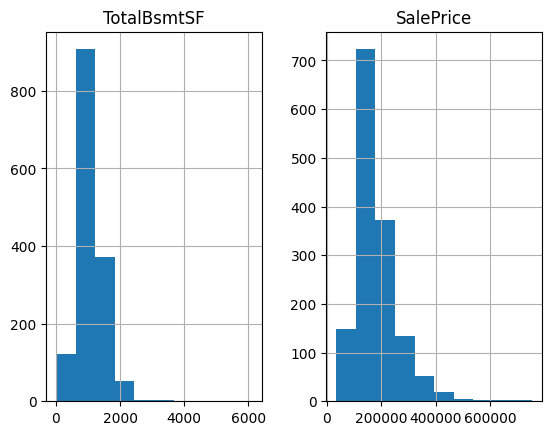

In [228]:
df[["TotalBsmtSF","SalePrice"]].hist()

In [229]:
df["TotalBsmtSF_log"] = np.log1p(df["TotalBsmtSF"])

In [231]:
df.groupby("Heating")["SalePrice"].mean().sort_values()

Heating
Floor     72500.000000
Grav      75271.428571
Wall      92100.000000
OthW     125750.000000
GasW     166632.166667
GasA     182021.195378
Name: SalePrice, dtype: float64

In [233]:
df["Heating"].value_counts()
df["Heating"] = (df["Heating"] == "GasA").astype(int)